# IMAGE - Tính và trực quan hóa phân phối giá trị pixel trên toàn tập (histogram, KDE) theo từng kênh màu.

# Mục lục
1. [Lý thuyết về Histogram và KDE](#sec-1)
    - [1.1. Phân phối dữ liệu:](#sec-1-1)
    - [1.2. Histogram](#sec-1-2)
    - [1.3. Kernel Density Estimation - KDE](#sec-1-3)
    - [1.4. Time Complexity](#sec-1-4)
2. [Nhận xét phân phối Histogram](#sec-2)
3. [Nhận xét phân phối KDE](#sec-3)
4. [Phân phối theo Class](#sec-4)


<a id="sec-1"></a>
# 1. Lý thuyết về Histogram và KDE

<a id="sec-1-1"></a>
## 1.1. Phân phối dữ liệu: 
Trong xử lý ảnh số, mỗi bức ảnh được cấu thành từ các pixel mang giá trị cường độ sáng (thường từ 0 đến 255). Việc mô tả phân phối là quá trình thống kê tần suất xuất hiện của các giá trị này giúp xác định:

* **Tính tập trung:** Dữ liệu tập trung ở những khoảng nào.
* **Độ phân tán:** Dữ liệu trải rộng hay thu hẹp.
* **Hình dạng:** Dữ liệu có đối xứng (phân phối chuẩn), lệch trái/phải (skewed), nhiều đỉnh (multimodal).
* **Về mặt thống kê:** Phân phối cho biết đặc điểm dữ liệu ảnh, giúp nhận diện ảnh quá tối (underexposed), quá sáng (overexposed),...
* **Về mặt học máy:** Việc xác định được phân phối pixel có thể giúp chọn ra phương pháp chuẩn hóa (Normalization) phù hợp, nhằm đưa dữ liệu về một khoảng giá trị ổn định, giúp các thuật toán như KNN, Logistic Regression hội tụ nhanh hơn.
<a id="sec-1-2"></a>
## 1.2. Histogram
**Histogram**: là một kỹ thuật thống kê biểu diễn sự phân phối thực nghiệm của tập dữ liệu liên tục. Trong phần này, dữ liệu là cường độ sáng của các pixel.

<figure style="text-align: center;">
  <img src="./assets/histogram.png" alt="RGB image">
</figure>

**Cách xác định**
* **Chia thùng (Binning):** Toàn bộ dải giá trị của pixel (thường là $[0, 255]$) được chia thành $L$ khoảng gọi là bins.
* **Đếm:** Với mỗi pixel có giá trị thuộc về thùng nào và tăng giá trị đếm của thùng đó.

**Ý nghĩa**
* **Xác định phân phối cường độ sáng:** dựa vào biểu đồ có thể xác định vùng tối (lệch trái), vùng sáng (lệch phải) hay vùng trung tính.
* **Đánh giá độ tương phản:** Dải Histogram rộng và trải đều sẽ biểu thị độ tương phản cao. Histogram co cụm sẽ cho biết độ tương phản thấp.
* **Phát hiện hiện tượng "cháy" ảnh:** Nếu các cột tại giá trị cực biên (0 hoặc 255) vọt cao bất thường, ảnh có thể đã bị mất chi tiết ở vùng tối hoặc vùng sáng.

**Hạn chế**: 
* Trong một khoảng (ví dụ $[10, 20]$), mọi giá trị pixel từ $11$ đến $20$ đều được gộp chung vào một cột. Histogram coi trọng số của chúng là như nhau, dẫn đến việc không thể phân biệt được sự phân bổ chi tiết bên trong mỗi khoảng. 
* Có thể giải hạn chế trên bằng cách tăng số lượng khoảng. Tuy nhiên, nếu quá nhiều, biểu đồ sẽ bị răng cưa và gây nhiễu cho việc quan sát xu hướng tổng quát, nếu chọn số lượng khoảng quá ít, biểu đồ sẽ quá thô và mất đặc trưng.

<a id="sec-1-3"></a>
## 1.3. Kernel Density Estimation - KDE

**KDE:** là một phương pháp làm mịn dữ liệu giúp ước lượng hàm mật độ xác suất (Probability Density Function - PDF) của một biến ngẫu nhiên. Khác với Histogram mang tính rời rạc và phụ thuộc vào cách chia thùng, KDE tạo ra một đường cong liên tục, giúp quan sát hình dáng phân phối một cách tổng quát và ít nhiễu hơn.

Hàm ước lượng tại điểm $x$ được xác định bởi công thức:$$\hat{f}_h(x) = \frac{1}{nh} \sum_{i=1}^{n} K\left(\frac{x - x_i}{h}\right)$$

Trong đó:

* $n$: Tổng số pixel.

* $h$ (Bandwidth): quyết định độ mịn của đường cong.
* $K$: Hàm nhân (Kernel function - thường là phân phối chuẩn Gaussian)

<figure style="text-align: center;">
  <img src="./assets/kde.png" alt="RGB image">
</figure>

**Điểm khác biệt so với Histogram**

Sự khác biệt cốt lõi của KDE so với Histogram nằm ở cách xử lý từng pixel. Thay vì phân loại vào các thùng rời rạc, mỗi pixel $x_i$ trong tập dữ liệu sẽ được đại diện bởi một hàm nhân $K$.

Hàm mật độ tổng thể $\hat{f}_h(x)$ là tổng cộng dồn của tất cả các hàm Gaussian nhỏ này tại mọi vị trí. Nhờ tính chất khả vi liên tục của hàm Gaussian, kết quả tổng hợp luôn là một đường cong liền mạch, loại bỏ các nhiễu răng cưa thường thấy ở Histogram. Hệ số băng thông (Bandwidth) $h$ có vai trò quan trọng trong quá trình này:
- **$h$ quá nhỏ (Under-smoothed):** Tương đương với việc phương sai của hàm Gaussian rất hẹp. Hàm KDE sẽ hội tụ quá sát vào từng điểm dữ liệu cục bộ, dẫn đến hiện tượng nhiễu (noise) và xuất hiện nhiều đỉnh giả.
- **$h$ quá lớn (Over-smoothed):** Phương sai mở rộng, làm là phẳng các đỉnh của hàm Gaussian. Biểu đồ sẽ mất đi các đặc trưng cấu trúc quan trọng như tính đa đỉnh (multimodal).
- **Lựa chọn $h$ tối ưu:** thay vì chọn thủ công, các thư viện như seaborn hay scipy tự động tính toán $h$ thông qua các quy tắc tối ưu hóa sai số (MISE), thường là Quy tắc Scott và Quy tắc Silverman. Các phương pháp này dựa trên độ lệch chuẩn ($\sigma$) và số lượng mẫu ($n$) của tập dữ liệu để tìm ra "điểm rơi" lý tưởng giúp đường cong đủ mịn để loại bỏ nhiễu nhưng vẫn giữ được các đặc trưng phân phối.

**Ý nghĩa:** KDE khắc phục nhược điểm của Histogram bằng cách tạo ra một hàm mật độ xác suất liên tục.
* **Tính liên tục:** Giúp so sánh sự thay đổi phân phối giữa các lớp (class) một cách trực quan và khoa học hơn so với các cột rời rạc của Histogram.
* **Xác định hình dáng thực của phân phối:** KDE giúp làm mịn các nhiễu cục bộ, giúp ta xác định rõ các đỉnh (peaks) và thung lũng (valleys) của phân phối đặc trưng.
* **So sánh phân phối:** Nhờ tính liên tục, KDE cực kỳ hiệu quả khi cần vẽ chồng nhiều phân phối (so sánh các kênh màu RGB hay so sánh dữ liệu trước/sau khi chuẩn hóa) để nhận diện sự thay đổi về mặt thống kê.

<a id="sec-1-4"></a>
## 1.4. Time Complexity

| Tiêu chí | Histogram | KDE |
| :--- | :--- | :--- |
| **Bản chất** | Là **Phép đếm** rời rạc đơn giản. | Là **Phép nội suy (Interpolation)** liên tục sử dụng hàm mũ phi tuyến tính ($e^x$). |
| **Độ phức tạp** | **$O(N)$** | **$O(N \times M)$** |
| **Phân tích** | $N$: Tổng số pixel.| $N$: Tổng số pixel. $M$: Số điểm lưới trên trục đồ thị cần vẽ.|
| **Cơ chế** |Thuật toán chỉ đi qua từng pixel đúng 1 lần. Tại mỗi pixel xác định pixel thuộc khoảng nào.| Tại mỗi điểm $M$, thuật toán phải tính toán tầm ảnh hưởng của toàn bộ $N$ pixel thông qua các hàm mũ phi tuyến ($e^x$).|

In [1]:
import sys, os, warnings
import numpy as np
warnings.filterwarnings("ignore")
os.environ["OPENCV_LOG_LEVEL"] = "SILENT"

# 1. Bật chế độ hiển thị Inline và tự động nạp lại module
%matplotlib inline
%load_ext autoreload
%autoreload 2

# 2. Khai báo đường dẫn src để import module
sys.path.append(os.path.abspath(os.path.join('..', 'src')))

from image.dataset import ImageDataset
from image.analysis_pixel_distribution import PixelDataExtractor
from visualization.distribution import plot_histogram, plot_kde, plot_distribution_by_class
import visualization.distribution as dist # Import thẳng module để hack

# IMPORT PATH TỪ CONFIG SETTINGS
from config.settings import PATH_FOLDER_IMAGE_RAW

# 3. HACK CHO WSL: Ép plt.show() bên trong file distribution.py thành lệnh display()
from IPython.display import display
dist.plt.show = lambda: display(dist.plt.gcf())

# 4. Khởi tạo Dataset dùng Path chuẩn
print(f"[INFO] Khởi tạo Dataset từ: {PATH_FOLDER_IMAGE_RAW} ...")
dataset = ImageDataset(path=PATH_FOLDER_IMAGE_RAW)

# 5. Sử dụng Service trích xuất dữ liệu chuẩn Visitor Pattern
extractor = PixelDataExtractor(target_size=(64, 64))
dataset.accept(extractor)

# 6. Gán dữ liệu ra các biến Global để các Cell bên dưới sử dụng
images = extractor.images
labels = extractor.labels
pixel_data_all = extractor.pixel_data_all

# Lấy danh sách tên class (Ví dụ: ['dog', 'cat',...]) từ class_idx của dataset
class_names = list(dataset.class_idx.keys())

[INFO] Khởi tạo Dataset từ: D:\24_25\Data_mining\fix_2\data-mining-preprocessing-project\data\image ...
[PROCESS] Đang trích xuất dữ liệu pixel theo Batch (Resize (64, 64))...
 -> Đã trích xuất: 26179 / 26179 ảnh...
[INFO] Đang chuyển đổi sang định dạng Numpy Array...
[SUCCESS] Hoàn tất! Tổng số lượng pixel thu được: 107,229,184 pixels
Bước xử lý : Pixel Data Extraction
Tập dữ liệu: D:\24_25\Data_mining\fix_2\data-mining-preprocessing-project\data\image
Trạng thái : Success


--- PHÂN PHỐI HISTOGRAM TỔNG THỂ ---


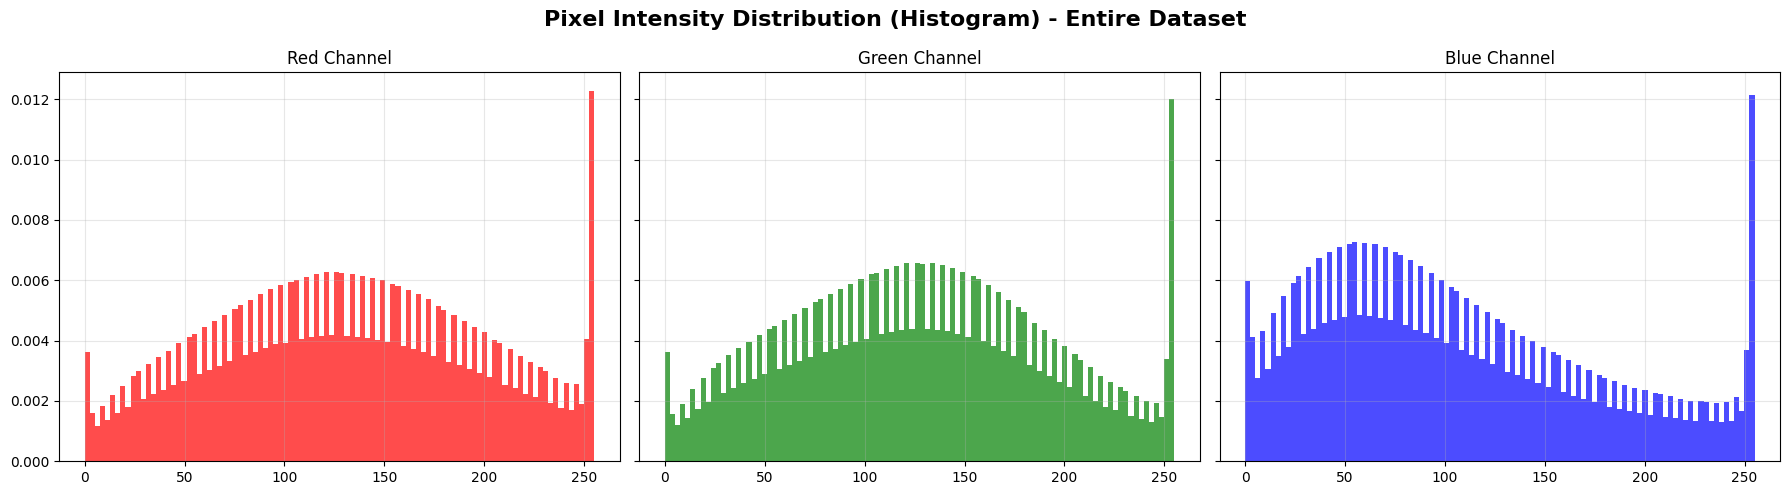

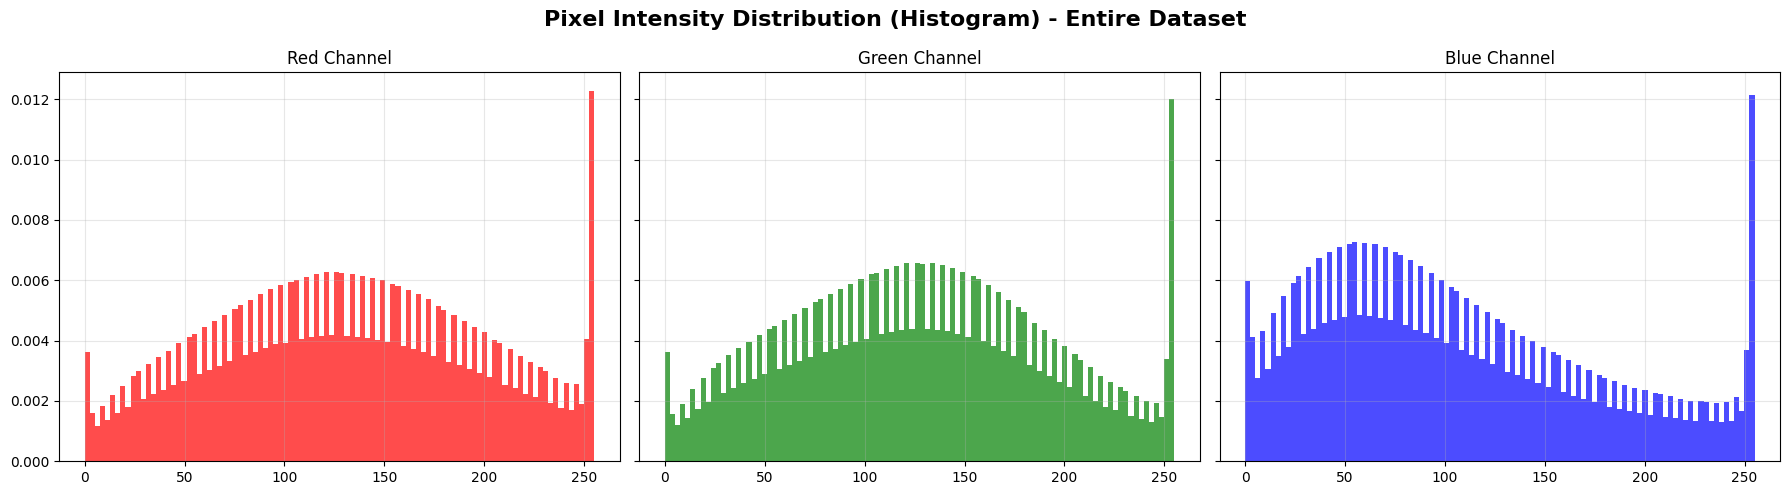

In [2]:
# Gọi hàm vẽ Histogram trên toàn bộ tập dữ liệu
print("--- PHÂN PHỐI HISTOGRAM TỔNG THỂ ---")
plot_histogram(pixel_data_all, title_suffix="- Entire Dataset")

<a id="sec-2"></a>
# 2. Nhận xét phân phối Histogram

Dua tren bieu do Histogram cua 3 kenh mau (Red, Green, Blue) tren toan tap du lieu:

**1. Dạng biểu đồ:**

- Cả 3 kênh màu đều có phân phối phức tạp, không tuân theo phân phối chuẩn.
- Kênh Red: mật độ pixel phân bố dày và trải dài ở dải giá trị từ 100 đến 200.
- Kênh Green: phân bố rộng, hình dạng thoải thoải, tập trung nhiều ở dải trung tính từ 50 đến 200.
- Kênh Blue: lệch trái rõ rệt, tập trung lượng lớn pixel ở dải giá trị thấp từ 0 đến 100.

**2. Độ sáng từng kênh màu:**
- Kênh Red có nhiều pixel ở vùng sáng, phản ánh tập ảnh chứa lượng lớn sắc tố mang tông ấm (đỏ, cam, nâu).
- Kênh Blue tập trung pixel ở vùng tối, cho thấy hình ảnh thiếu hụt nguồn sáng xanh dương.

**3. So sánh giữa các kênh:**
- Tại vùng sáng (giá trị > 150), kênh Red áp đảo so với Blue. Ở vùng tối (< 50), kênh Blue chiếm ưu thế về mật độ.
- Kết luận: Tập dữ liệu có sự mất cân bằng màu sắc tự nhiên, thiên về tông ấm.

**4. DĐộ tương phản:**
- Biểu đồ trải rộng từ 0 đến 255, không bị co cụm. Tập dữ liệu có độ tương phản tốt, chi tiết phân bố từ vùng tối đến vùng sáng.

**5. Hiện tượng clip tại giá trị 255:**
- Xuất hiện các cột vọt cao đột biến ở cả 3 kênh tại giá trị 255. Đây là dấu hiệu mất chi tiết vùng sáng.
- Nguyên nhân chủ yếu do nhiều ảnh sử dụng nền trắng (R = G = B = 255) để làm nổi bật chủ thể.

--- PHÂN PHỐI KDE TỔNG THỂ ---


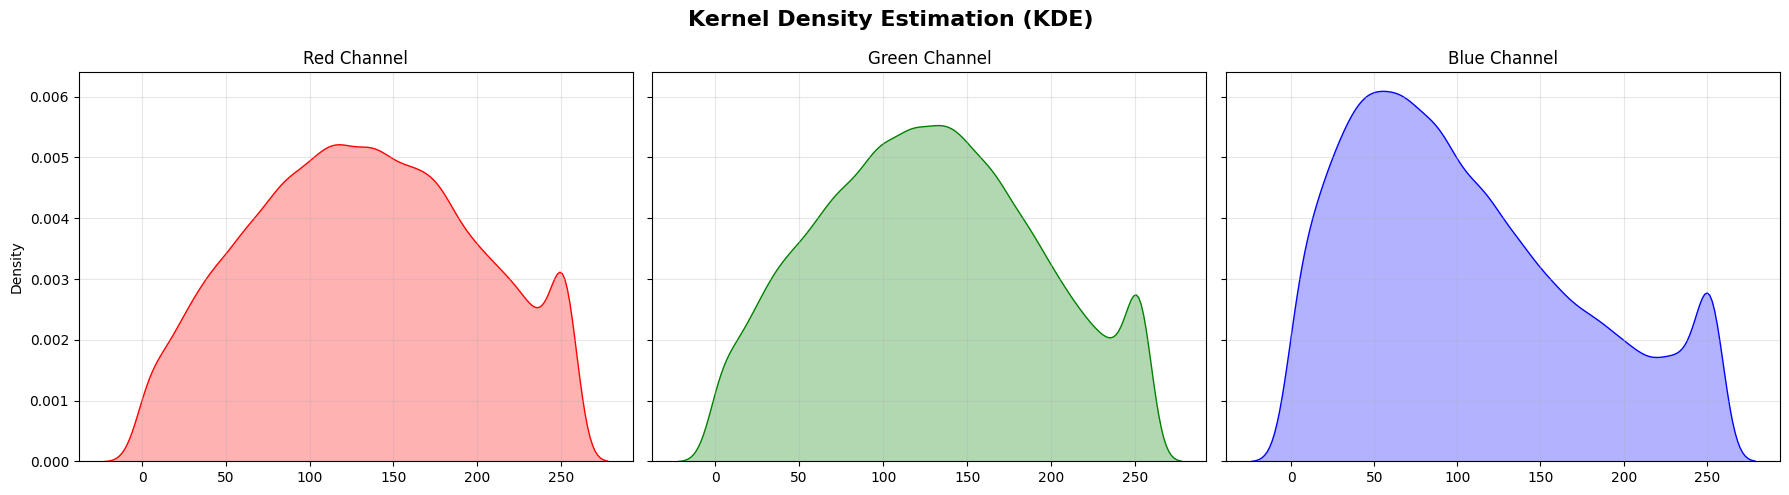

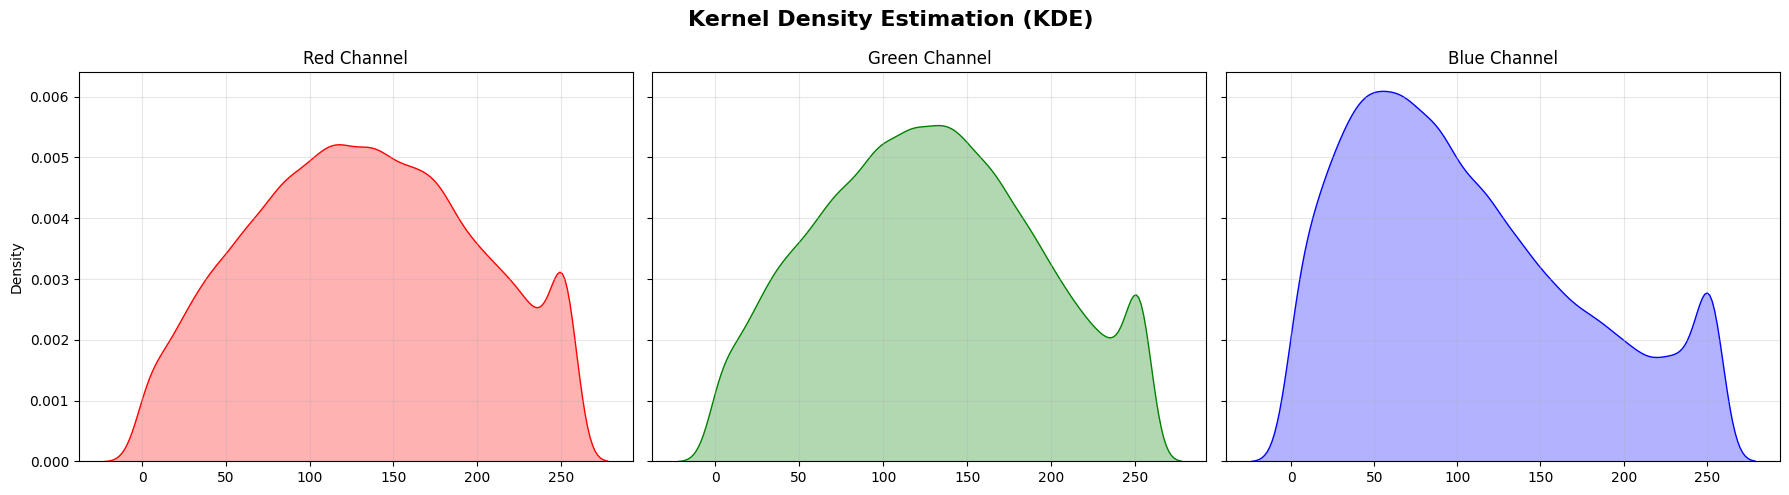

In [3]:
# Gọi hàm vẽ KDE trên toàn bộ tập dữ liệu
print("--- PHÂN PHỐI KDE TỔNG THỂ ---")
plot_kde(pixel_data_all, title_suffix="")

<a id="sec-3"></a>
# 3. Nhận xét phân phối KDE

**1. Vị trí đỉnh phân phối:**
- Kênh Red: đỉnh tạo thành dải rộng và cao ở khu vực giá trị từ 100 đến 150, khẳng định ưu thế của sắc đỏ ở vùng trung tính và sáng.
- Kênh Blue: đỉnh nhọn và cao vọt ở vùng giá trị khoảng 50, cho thấy mật độ pixel xanh dương tập trung rất lớn ở vùng tối.
- Kênh Green: đường cong trải rộng, không có một đỉnh duy nhất rõ ràng, phản ánh sự phân bố đồng đều hơn.

**2. Độ rộng đường cong:**
- Cả 3 kênh có đường cong KDE bao phủ gần như toàn bộ dải giá trị từ 0 đến 255, qua đó khẳng định độ tương phản cao của tập dữ liệu.

**3. Vị trí đỉnh và xu hướng màu:**
- Đỉnh của kênh Blue lệch trái rất nhiều trong khi kênh Red và Green khá giống nhau. Sự lệch này cho thấy ảnh sẽ thiên về các sắc tố tự nhiên mang tone màu ấm.

--- PHÂN PHỐI KDE THEO TỪNG CLASS ---


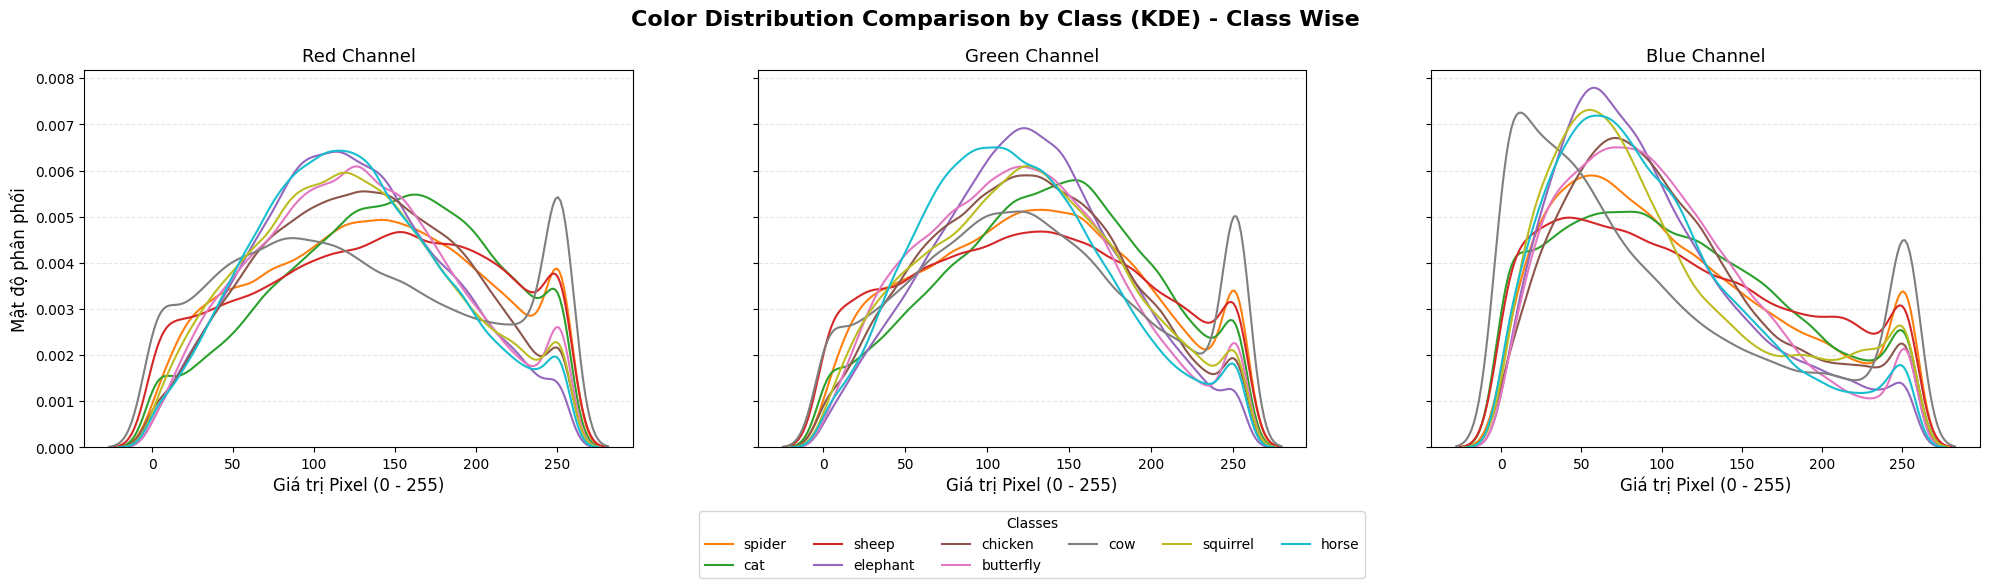

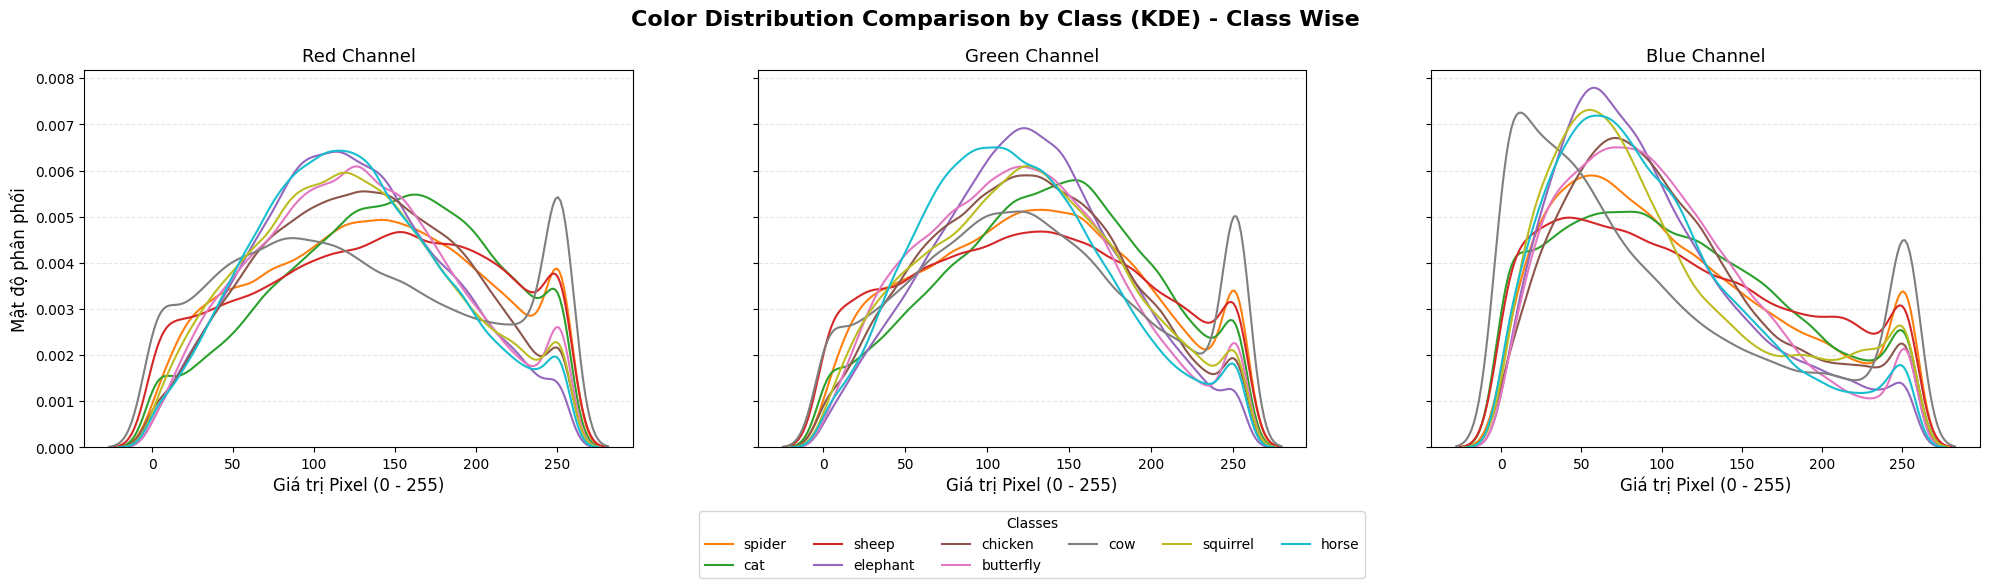

In [4]:
print("--- PHÂN PHỐI KDE THEO TỪNG CLASS ---")
plot_distribution_by_class(images, labels, class_names, title_suffix="- Class Wise")

<a id="sec-4"></a>
# 4. Phân phối theo Class
- Kênh Blue bị lệch trái: Lớp cow, elephant, squirrel có đỉnh cao ở vùng giá trị thấp (khoảng 30-60). Đây là nguyên nhân chính tạo đỉnh nhọn ở vùng tối của kênh Blue trong biểu đồ tổng.
- Dù biểu đồ chỉ ra sắc đỏ, xanh lá cây, xanh biển có lệch, biến động không đều, không đúng với các phân bố chuẩn, nhưng nó thể hiện đặc trưng của dữ liệu, việc chỉnh lại dữ liệu sao cho phân bố "đều và đẹp" có thể làm mất đi tính đặc trưng của dữ liệu, như mất đi sắc tố của các loài mang màu đỏ, cam (như spider, cat), từ đó dữ mất đi ý nghĩa của nó dẫn đến khi đưa vào các mô hình sẽ cho kết quả dự đoán sai.